<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Decision_Tree_FinalModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [159]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

In [160]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_DT.csv')
# Copy data
churn_data = df.copy()

In [161]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)

churn_data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,TotalCharges_numeric,AvgChargePerMonth
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,0,29.85,14.925000
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,0,1889.50,53.985714
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,1,108.15,36.050000
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,0,1840.75,40.016304
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,1,151.65,50.550000


In [162]:
from sklearn.model_selection import train_test_split

# List of zero-importance features
zero_importance_features = [
    'gender', 'Partner', 'SeniorCitizen', 'DeviceProtection',
    'InternetService', 'PaperlessBilling', 'StreamingMovies',
    'StreamingTV', 'AvgChargePerMonth'
]

# Separate features and target, dropping zero-importance features
X = churn_data.drop(columns=['Churn'] + zero_importance_features)
y = churn_data['Churn']

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # ensures the target class distribution is preserved
)

# Check shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts(normalize=True))
print("y_test distribution:\n", y_test.value_counts(normalize=True))

X_train shape: (5634, 11)
X_test shape: (1409, 11)
y_train distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
y_test distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [163]:
# Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [154]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier

# Parameter grid
param_grid = {
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [20, 50, 100],
    'ccp_alpha': [0.0, 0.001, 0.005, 0.01],
    'criterion': ['gini', 'entropy']
}
# GridSearchCV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_res, y_train_res)
print("Best params:", grid_search.best_params_)
print("Best F1:", grid_search.best_score_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best params: {'ccp_alpha': 0.001, 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 20, 'min_samples_split': 10}
Best F1: 0.8148681661814727


In [164]:
# Decision Tree Classifier
print("\n--- Decision Tree Model ---\n")

# Define the model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=20,
    ccp_alpha=0.005,
    criterion='entropy'
)

# Fit the model
dt_model.fit(X_train_res, y_train_res)

# Threshold Tuning
best_f1 = 0
best_threshold = 0.5  # default
threshold_start = 0.1
threshold_stop = 0.7
threshold_step = 0.01

dt_test_prob = dt_model.predict_proba(X_test)[:,1]

for threshold in np.arange(threshold_start, threshold_stop, threshold_step):
    dt_test_pred = (dt_test_prob >= threshold).astype(int)
    f1 = f1_score(y_test, dt_test_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Best Threshold for max F1: {best_threshold:.2f}, F1-score: {best_f1:.4f}")

# Predictions for train set
dt_train_prob = dt_model.predict_proba(X_train_res)[:,1]
dt_train_pred = (dt_train_prob >= best_threshold).astype(int)

# Metrics
dt_train_auc = roc_auc_score(y_train_res, dt_train_prob)
dt_test_auc = roc_auc_score(y_test, dt_test_prob)
dt_train_acc = accuracy_score(y_train_res, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

# Overfitting / Underfitting Check
if dt_train_auc - dt_test_auc > 0.1 or dt_train_acc - dt_test_acc > 0.1:
    print("Warning: Potential Overfitting Detected (Significant Gap between Train and Test metrics)")
elif dt_train_auc < 0.65 and dt_test_auc < 0.65:
    print("Warning: Potential Underfitting Detected (Low Train and Test metrics)")
else:
    print("No major overfitting or underfitting detected")


--- Decision Tree Model ---

Best Threshold for max F1: 0.43, F1-score: 0.6077
No major overfitting or underfitting detected


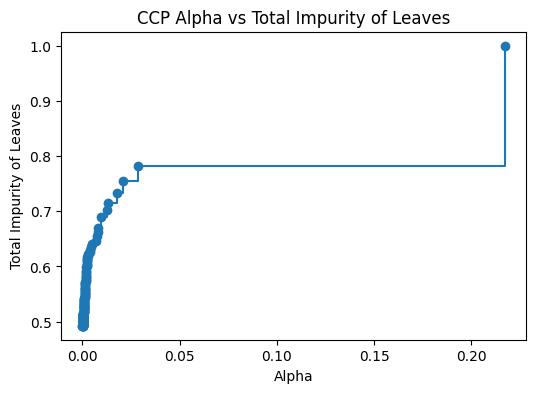

/tmp/ipython-input-1585554416.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


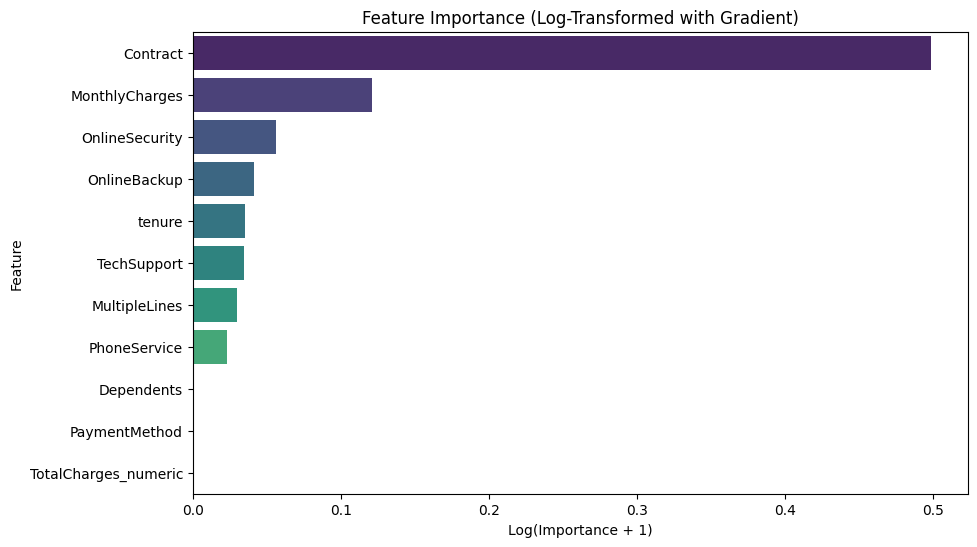

F1-scores for each fold: [0.81045752 0.81864696 0.81332567 0.81103286 0.82087782]
Mean F1-score (CV): 0.8148681661814727

--- Train Evaluation ---

Accuracy: 0.7876
Recall: 0.8265
Precision: 0.7669
F1-score: 0.7956
ROC Score (Discrete Prediction): 0.7876
AUC Score (Probability): 0.8668

Classification Report:
              precision    recall  f1-score   support

           0     0.8119    0.7487    0.7790      4139
           1     0.7669    0.8265    0.7956      4139

    accuracy                         0.7876      8278
   macro avg     0.7894    0.7876    0.7873      8278
weighted avg     0.7894    0.7876    0.7873      8278

Confusion Matrix:
[[3099 1040]
 [ 718 3421]]


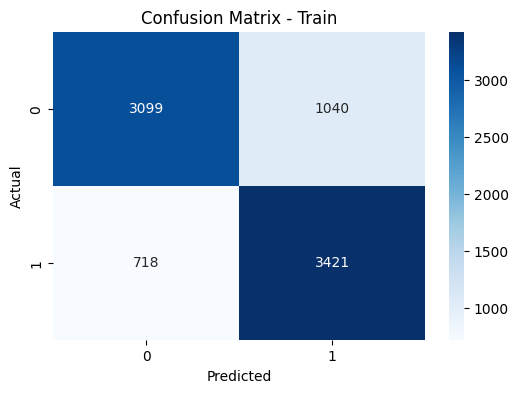

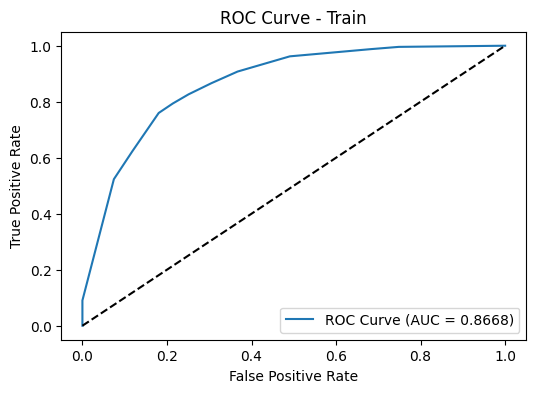

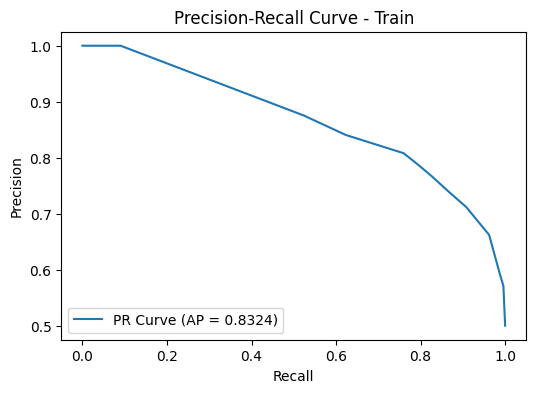


--- Test Evaluation ---

Accuracy: 0.7480
Recall: 0.7353
Precision: 0.5179
F1-score: 0.6077
ROC Score (Discrete Prediction): 0.7440
AUC Score (Probability): 0.8167

Classification Report:
              precision    recall  f1-score   support

           0     0.8872    0.7527    0.8144      1035
           1     0.5179    0.7353    0.6077       374

    accuracy                         0.7480      1409
   macro avg     0.7026    0.7440    0.7111      1409
weighted avg     0.7892    0.7480    0.7596      1409

Confusion Matrix:
[[779 256]
 [ 99 275]]


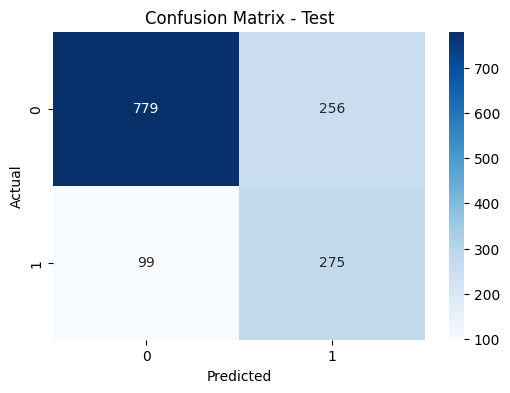

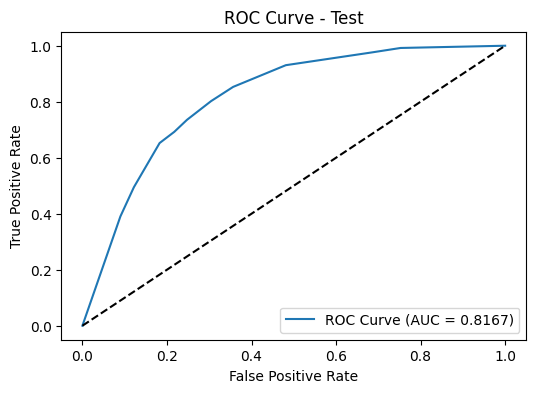

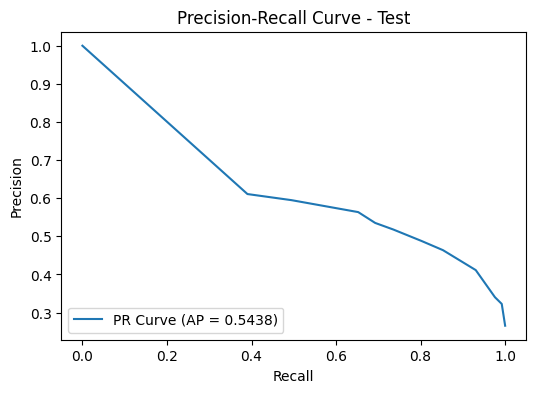

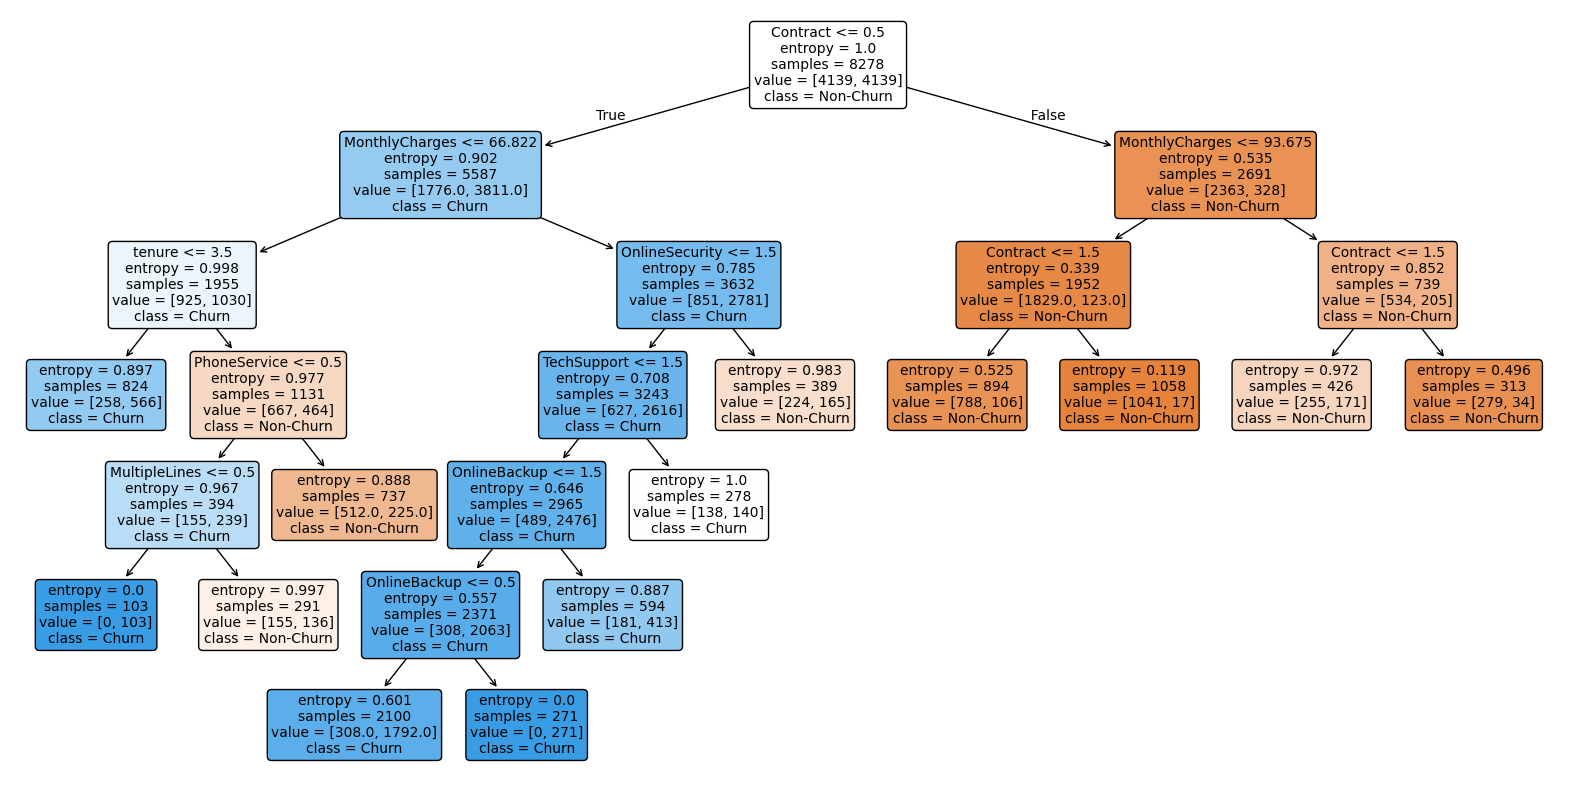

In [165]:
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score,
    roc_auc_score, roc_curve, auc, classification_report, confusion_matrix, precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
import numpy as np

# Visualizing CCP Alpha vs Impurity
path = dt_model.cost_complexity_pruning_path(X_train_res, y_train_res)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

plt.figure(figsize=(6,4))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Total Impurity of Leaves")
plt.title("CCP Alpha vs Total Impurity of Leaves")
plt.show()

# Feature Importance Plot with Gradient and Log Transformation
feature_importance = pd.DataFrame({
    'Feature': X_train_res.columns,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Apply log transformation (add a small value to avoid log(0))
feature_importance['LogImportance'] = np.log1p(feature_importance['Importance'])

plt.figure(figsize=(10,6))
sns.barplot(
    x='LogImportance',
    y='Feature',
    data=feature_importance,
    palette="viridis"  # gradient color
)
plt.xlabel("Log(Importance + 1)")
plt.title("Feature Importance (Log-Transformed with Gradient)")
plt.show()

from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, make_scorer

# F1 scorer
f1_scorer = make_scorer(f1_score)

# 5-fold stratified CV
f1_scores = cross_val_score(
    grid_search.best_estimator_,  # or your chosen model
    X_train_res,
    y_train_res,
    cv=skf,
    scoring=f1_scorer
)

print("F1-scores for each fold:", f1_scores)
print("Mean F1-score (CV):", f1_scores.mean())

# Function to Evaluate a Dataset
def evaluate_decision_tree(model, X, y, dataset_name="Test"):
    print(f"\n--- {dataset_name} Evaluation ---\n")

    # Predictions
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= best_threshold).astype(int)

    # Metrics
    acc = accuracy_score(y, y_pred)
    rec = recall_score(y, y_pred)
    prec = precision_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    roc_score = roc_auc_score(y, y_pred)
    auc_score = roc_auc_score(y, y_prob)

    print(f"Accuracy: {acc:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(f"ROC Score (Discrete Prediction): {roc_score:.4f}")
    print(f"AUC Score (Probability): {auc_score:.4f}\n")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y, y_pred, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y, y_pred)
    print("Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc='lower right')
    plt.show()

    # Precision-Recall Curve
    precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_prob)
    ap_score = average_precision_score(y, y_prob)
    plt.figure(figsize=(6,4))
    plt.plot(recall_vals, precision_vals, label=f'PR Curve (AP = {ap_score:.4f})')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {dataset_name}")
    plt.legend(loc='lower left')
    plt.show()

    return acc, rec, prec, f1, roc_score, auc_score

# Evaluate on Train and Test
train_metrics = evaluate_decision_tree(dt_model, X_train_res, y_train_res, "Train")
test_metrics = evaluate_decision_tree(dt_model, X_test, y_test, "Test")

# Display the Decision Tree
plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_model,
    feature_names=X_train_res.columns,
    class_names=["Non-Churn","Churn"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

In [166]:
import joblib

# Save the trained model
model_path = '/content/drive/MyDrive/DT_Model/dt_model_final.pkl'
joblib.dump(dt_model, model_path)
print(f"Decision Tree model saved at: {model_path}")

# Save the best threshold found during tuning
threshold_path = '/content/drive/MyDrive/DT_Model/best_threshold.pkl'
joblib.dump(best_threshold, threshold_path)
print(f"Best threshold saved at: {threshold_path}")

Decision Tree model saved at: /content/drive/MyDrive/DT_Model/dt_model_final.pkl
Best threshold saved at: /content/drive/MyDrive/DT_Model/best_threshold.pkl


In [ ]:
# Load the saved model and threshold
model_path = '/content/drive/MyDrive/dt_model_final.pkl'
threshold_path = '/content/drive/MyDrive/best_threshold.pkl'

dt_model = joblib.load(model_path)
best_threshold = joblib.load(threshold_path)

print("Model and threshold loaded successfully!")